<a href="https://colab.research.google.com/github/aminmoosavi/__PyTorch__/blob/main/PyTorch_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PyTorch Day-3**

* **In this notebook we will learn to solve a binary classification problem with neural networks**


**Check for the GPU**

 NVIDIA System Management Interface (smi)

In [1]:
!nvidia-smi

Tue Jul  7 01:37:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P0             30W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
from torch import nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Use gpu if available.
device="cuda" if torch.cuda.is_available() else "cpu"

**PyTorch Version**

In [4]:
torch.__version__

'2.11.0+cu128'

* # The data.

We want to do a binary classification of two quadratic data sets

* $y_1 = a_1 x^2 + b_1 x + c_1 + \eta_1$ and
* $y_2 = a_2 x^2 + b_2 x + c_2 + \eta_2$

where \eta_1 and \eta_2 are Gaussian noises



In [5]:
a1 , b1 , c1 = 1 , -2 , 4
a2 , b2 , c2 = 1 , -2 , 10
x_min , x_max = -4 ,  6

# Setting the random seed
torch.manual_seed(21)



# Input data

# X = torch.arange().unsqueeze(dim=1)
X1 = (x_max - x_min) * torch.rand(1000, 1) + x_min
X2 = (x_max - x_min) * torch.rand(1000, 1) + x_min


# Observed output
Y1 = a1 * X1**2 + b1 * X1 + c1 + torch.randn(X1.size())
y1 = torch.ones(X1.size())
Y2 = a2 * X2**2 + b2 * X2 + c2 + torch.randn(X2.size())
y2 = torch.zeros(X2.size())

X = torch.cat( ( X1 , X2), dim = 0) # <-- Data first dimension
Y = torch.cat( ( Y1 , Y2), dim = 0) # <-- Data second dimension
y = torch.cat( ( y1 , y2), dim = 0) # <-- Labels

# randomly permute the data
shuffled_indices = torch.randperm(X.size()[0])

X = X[shuffled_indices]
Y = Y[shuffled_indices]

X = torch.cat((X,Y),dim=1) # <-- Two dimensional input
y = y[shuffled_indices] # <-- One dimensional labels (zeros and ones)


print('The data is on', X.device)

print('Moving the data to gpu if available')

X = X.to(device)
y = y.to(device)

print('The data is on', X.device, 'now')

The data is on cpu
Moving the data to gpu if available
The data is on cuda:0 now


* # Visualize the data

Our goal is to classify the red and black points

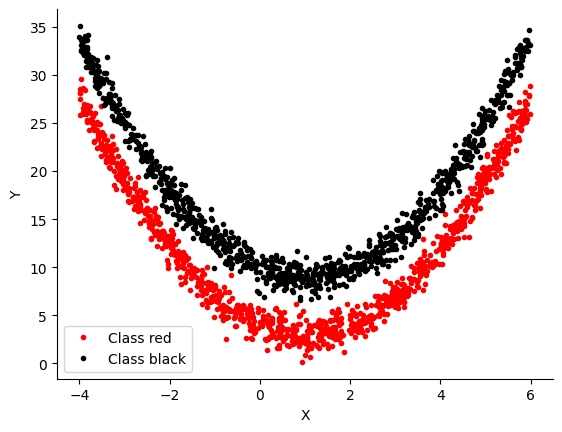

In [6]:
fig, ax = plt.subplots()
# ax.plot(X_test,Y_test,'r.',label='Test Data')
# ax.plot(X_train,Y_train,'k.',label='Training Data')
ax.plot(X1,Y1,'r.',label='Class red')
ax.plot(X2,Y2,'k.',label='Class black')
ax.set_ylabel('Y')
ax.set_xlabel('X')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()

* # Splitting the data into training and test sets

In [7]:
train_split = int(0.75 * len(y))

# Splitting the data
X_train , y_train = X[:train_split,:]  , y[:train_split]
X_test , y_test = X[train_split:,:]  , y[train_split:]


X_train.device

device(type='cuda', index=0)

* # Build the model

Because the input is two dimensional the in_features of layer 1 must be 2
The output are some numbers called logits (they will be passed to a sigmoid that gives us probability of the input being in class red or class black)

In [8]:
class BinaryClassificationModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2 , out_features=200)
    self.layer2 = nn.Linear(in_features=200 , out_features=1)
    self.activation = nn.ReLU()

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.layer1(x)
    x = self.activation(x)
    x = self.layer2(x)
    return x



In [9]:
# Instantiate the model
model_3 = BinaryClassificationModel()
model_3.to(device)
# List the model attributes
list(model_3.state_dict())

['layer1.weight', 'layer1.bias', 'layer2.weight', 'layer2.bias']

* # Setting the loss function
The Binary Cross Entropy loss with the Logits expects logits as inputs. It then automatically applies the sigmoid and calculate the probability and then the loss.

In [10]:
loss_fn = nn.BCEWithLogitsLoss()

* # Setting the optimizer

In [11]:
optimizer = torch.optim.SGD(params=model_3.parameters(),
                            lr=0.1)

* # The training loop

In [12]:
epochs = 1000
losses=torch.zeros(epochs)
losses_test=torch.zeros(epochs)
for epoch in range(epochs):
  model_3.train() # training mode activated

  #1. forward pass
  y_logits = model_3(X_train)

  #2. Compute the loss
  loss=loss_fn(y_logits,y_train)
  losses[epoch]=loss # save the loss

  #3. Optimizer zero grad resets the gradient to zero
  optimizer.zero_grad()

  #4. Perform backpropagation
  loss.backward()

  #5. Step the optimizer (gradient descent)
  optimizer.step()

  #6. Look at how the model does on the test data
  model_3.eval() # Evaluation mode activated
  with torch.inference_mode():
    # forward pass the test data
    Y_logit_test = model_3(X_test)

    # calculate test loss
    loss_test=loss_fn(Y_logit_test,y_test)
    losses_test[epoch] = loss_test # save the loss

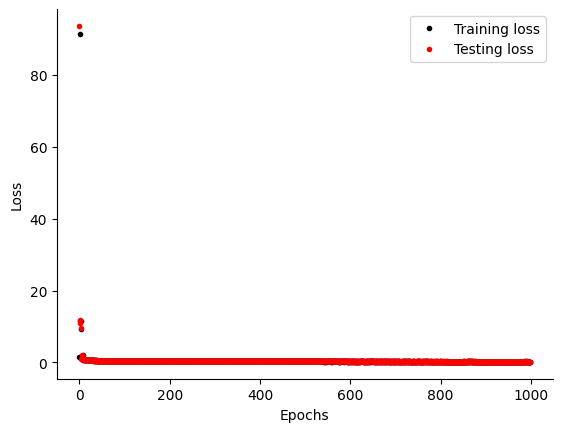

In [13]:
# Casting the loss tensors into NumPy arrays
lossvals=losses.detach().numpy()
lossvals_test=losses_test.detach().numpy()

# Plotting the loss functions
fig, ax = plt.subplots()
plt.plot(lossvals,'.',color='k',label = 'Training loss')
ax.plot(lossvals_test,'.',color='r',label = 'Testing loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()

* # Model predictions based on the probabilities

* ## Get labels from logits

In [14]:
# logits to labels

def logits_to_labels(x: torch.Tensor ):
  """
  input:
  x = raw logits

  output:
  binary tensor

  This function gets the logits as input
  1. Applys the sigmoid function and gets probabilities
  2. Uses a coint toss based on the probabilities to generate labels
  """
  probabilities = torch.sigmoid(x)
  q = torch.rand(probabilities.size() )
  return probabilities > q

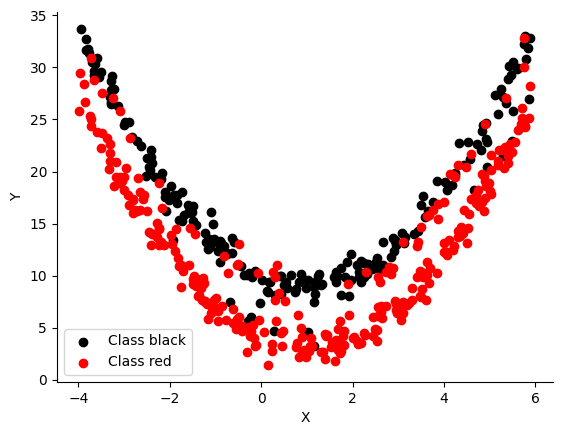

In [15]:
y_test_logits = model_3(X_test)
y_pred = logits_to_labels(y_test_logits.cpu()).squeeze()
fig, ax = plt.subplots()

ax.scatter(X_test.cpu()[y_pred.cpu()==0, 0],
            X_test.cpu()[y_pred.cpu()==0, 1],
            color='black',
            label='Class black')

ax.scatter(X_test.cpu()[y_pred.cpu()==1, 0],
            X_test.cpu()[y_pred.cpu()==1, 1],
            color='red',
            label='Class red')


ax.set_ylabel('Y')
ax.set_xlabel('X')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()


* # ROC analysis

AUC = 0.998


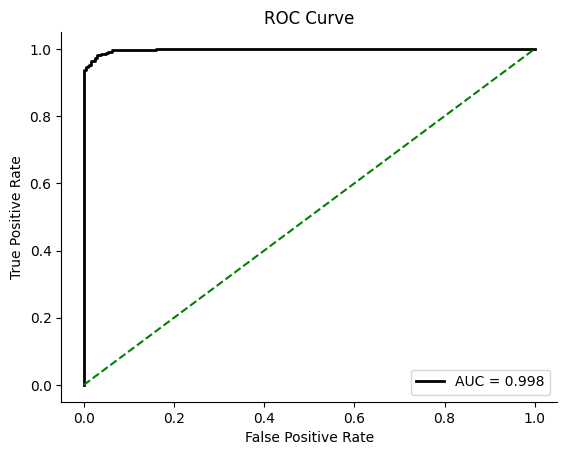

In [16]:
from sklearn.metrics import roc_curve, auc

# get the logits of the test data
y_test_logits = model_3(X_test)

# Evaluate the probabilities
probabilities = torch.sigmoid(y_test_logits)

# -----------------------
# ROC computation
# -----------------------
fpr, tpr, thresholds = roc_curve(
    y_test.cpu().numpy(),
    probabilities.cpu().detach().numpy()
)

roc_auc = auc(fpr, tpr)

print(f"AUC = {roc_auc:.3f}")

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots()

ax.plot(fpr, tpr,'k-', lw=2, label=f"AUC = {roc_auc:.3f}")
ax.plot([0,1], [0,1], 'g--')
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend()
# plt.grid(True)
plt.show()

* # Try different sizes of the hidden layer as well as diffeent activation functions to see how they can affect the classification.

* # Now try to implement the same binary classification using only linear layers (No nonlinearity such as ReLU, GELU, ...).

* Hint: Because the data is nonlinear (quadratic) it requires a quadratic decision boundary that would not be possible by only linear layers, no matter how big and deep the linear stack of layers are.  